In [160]:

import os
import sys
import json
import numpy as np
import pandas as pd


In [161]:

import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import xgboost as xgb
from xgboost import XGBClassifier
import shap

In [162]:
from sklearn.preprocessing import KBinsDiscretizer


In [163]:
#BASE_DIR      = os.path.dirname(os.path.dirname(os.path.abspath(current_dir)))

current_dir=os.getcwd()

BASE_DIR      = os.path.dirname(os.path.abspath(current_dir))
#
BRONZE_DIR    = os.path.join(BASE_DIR, "data", "Bronze layer")
SILVER_DIR    = os.path.join(BASE_DIR, "data", "Silver layer")
GOLD_DIR      = os.path.join(BASE_DIR, "data", "Gold layer")

ARTIFACTS_DIR = os.path.join(BASE_DIR, "main_scripts", "pipeline_artifacts")

SCALER_PATH  = os.path.join(ARTIFACTS_DIR, "scaler_params.json")
ENCODER_PATH = os.path.join(ARTIFACTS_DIR, "encoder_params.json")

In [164]:
SEED = 42
np.random.seed(SEED)
RNG  = np.random.default_rng(SEED)

OUT_DIR  = os.path.join(BASE_DIR, "main_scripts","Reports", "features_interactions")
os.makedirs(OUT_DIR, exist_ok=True)

os.makedirs(os.path.join(BASE_DIR, "main_scripts","Reports","feature_selection"), exist_ok=True)


##  Functions

In [165]:
def load_data(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Input file not found: {path}")
    df = pd.read_csv(path)
    print(f"  Loaded {os.path.basename(path)}: {df.shape}")
    return df

In [166]:

def silver_output_path(input_path: str) -> str:
    name = os.path.basename(input_path)
    stem = os.path.splitext(name)[0]
    return os.path.join(SILVER_DIR, f"{stem}_cleaned.csv")

In [167]:
def gold_output_path(input_path: str) -> str:
    name = os.path.basename(input_path)          # train_cleaned.csv
    stem = name.replace("_cleaned", "")           # train.csv
    stem = os.path.splitext(stem)[0]              # train
    return os.path.join(GOLD_DIR, f"{stem}_engineered.csv")


In [168]:

def basic_check(dgp):
 """
 Basic check of a dataframe, it checks dtypes, % null and # unique values
 """
 return dgp.dtypes.to_frame("dtype").join(
        dgp.isnull().mean().to_frame("null_%").round(3)
    ).join(dgp.nunique().to_frame("unique"))

### Artifacts functions

In [169]:
def save_artifacts(scaler_params: dict, encoder_params: dict) -> None:
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)
    with open(SCALER_PATH, "w") as f:
        json.dump(scaler_params, f, indent=2)
    with open(ENCODER_PATH, "w") as f:
        json.dump(encoder_params, f, indent=2)
    print(f"  Artifacts saved → {ARTIFACTS_DIR}/")


def load_artifacts() -> tuple[dict, dict]:
    missing = [p for p in (SCALER_PATH, ENCODER_PATH) if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(
            "Pipeline artifacts are missing — the training pipeline must be run first "
            "before applying inference transformations.\n"
            f"Missing files:\n" + "\n".join(f"  {p}" for p in missing)
        )
    with open(SCALER_PATH) as f:
        scaler_params = json.load(f)
    with open(ENCODER_PATH) as f:
        encoder_params = json.load(f)
    return scaler_params, encoder_params

In [170]:
def _apply_standard_scaler(df: pd.DataFrame, scaler_params: dict) -> pd.DataFrame:
    for col, stats in scaler_params.items():
        if col not in df.columns:
            raise ValueError(f"Expected numeric column '{col}' not found in input.")
        df[col] = (df[col] - stats["mean"]) / stats["std"]
    return df


def _apply_encoders(df: pd.DataFrame, encoder_params: dict, BINARY_COLS :dict ,ORDINAL_COLS :dict , CATEGORICAL_COLS:list) -> pd.DataFrame:
    # Fixed binary mappings
    for col, mapping in BINARY_COLS.items():
        if col not in df.columns:
            raise ValueError(f"Expected binary column '{col}' not found in input.")
        unseen = set(df[col].dropna().unique()) - set(mapping)
        if unseen:
            print(f"  [WARN] '{col}': unseen values {unseen} → mapped to -1")
        df[col] = df[col].map(mapping).fillna(-1).astype(int)

    # Fixed ordinal mappings
    for col, mapping in ORDINAL_COLS.items():
        if col not in df.columns:
            raise ValueError(f"Expected ordinal column '{col}' not found in input.")
        unseen = set(df[col].dropna().unique()) - set(mapping)
        if unseen:
            print(f"  [WARN] '{col}': unseen values {unseen} → mapped to -1")
        df[col] = df[col].map(mapping).fillna(-1).astype(int)

    # Learned categorical mappings (from train)
    for col in CATEGORICAL_COLS:
        if col not in df.columns:
            raise ValueError(f"Expected categorical column '{col}' not found in input.")
        mapping = encoder_params.get(col, {})
        unseen = set(df[col].dropna().unique()) - set(mapping)
        if unseen:
            print(f"  [WARN] '{col}': unseen categories {unseen} → mapped to -1")
        df[col] = df[col].map(mapping).fillna(-1).astype(int)

    return df


In [171]:
def to_z(scaler,col, raw_value):
    mean = scaler[col]["mean"]
    std  = scaler[col]["std"]
    return (raw_value - mean) / std


### IV functions

In [172]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning


# =========================================================
# Helper Function
# =========================================================
def fit_optimal_binning(df, feature, target_variable):
    """
    Fit optimal binning for a single feature.

    Returns:
    - binning_df : detailed binning table
    - overall_iv : Information Value
    """

    try:
        # Feature and target
        x = df[feature].copy()
        y = df[target_variable]

        # Replace infinite values
        x = x.replace([np.inf, -np.inf], np.nan)

        # Detect feature type automatically
        if pd.api.types.is_numeric_dtype(x):
            dtype = "numerical"
        else:
            dtype = "categorical"
            x = x.astype(str)

        # Create optimal binning object
        optb = OptimalBinning(
            name=feature,
            dtype=dtype,
            solver="cp"
        )

        # Fit model
        optb.fit(x, y)

        # Build binning table
        binning_df = optb.binning_table.build()

        # Ensure DataFrame
        if not isinstance(binning_df, pd.DataFrame):
            binning_df = pd.DataFrame(binning_df)

        # Overall IV
        overall_iv = optb.binning_table.iv

        # Add feature column
        binning_df.insert(0, "Feature", feature)

        return binning_df, overall_iv

    except Exception as e:
        print(f"Error processing feature {feature}: {e}")
        return pd.DataFrame(), np.nan


# =========================================================
# Calculate Detailed IV for All Features
# =========================================================
def calculate_information_value_detailed(df, target_variable):
    """
    Calculate Information Value (IV) for each feature
    and return detailed binning tables.

    Returns:
    - summary_df
    - detailed_tables
    """

    iv_summary = []
    detailed_tables = {}

    for feature in df.columns:

        if feature == target_variable:
            continue

        # Fit optimal binning
        binning_df, overall_iv = fit_optimal_binning(
            df,
            feature,
            target_variable
        )

        # Store detailed table
        if not binning_df.empty:
            detailed_tables[feature] = binning_df

        # Store IV summary
        iv_summary.append({
            "Feature": feature,
            "IV": overall_iv
        })

        print(f"Feature: {feature} | IV: {overall_iv:.6f}")

    # Create summary DataFrame
    summary_df = (
        pd.DataFrame(iv_summary)
        .sort_values("IV", ascending=False, na_position="last")
        .reset_index(drop=True)
    )

    return summary_df, detailed_tables


# =========================================================
# Get IV Summary Only
# =========================================================
def get_iv_summary(df, target_variable):
    """
    Return only summary IV table.
    """

    iv_summary = []

    for feature in df.columns:

        if feature == target_variable:
            continue

        _, overall_iv = fit_optimal_binning(
            df,
            feature,
            target_variable
        )

        iv_summary.append({
            "Feature": feature,
            "IV": overall_iv
        })

    summary_df = (
        pd.DataFrame(iv_summary)
        .sort_values("IV", ascending=False, na_position="last")
        .reset_index(drop=True)
    )

    return summary_df


# =========================================================
# Get Detailed Binning Table for One Feature
# =========================================================
def get_feature_binning_table(df, target_variable, feature_name):
    """
    Get detailed binning table for one feature.
    """

    return fit_optimal_binning(
        df,
        feature_name,
        target_variable
    )


# =========================================================
# Combine All Binning Tables
# =========================================================
def combine_all_binning_tables(df, target_variable):
    """
    Combine all feature binning tables into one DataFrame.
    """

    all_tables = []

    for feature in df.columns:

        if feature == target_variable:
            continue

        binning_df, overall_iv = fit_optimal_binning(
            df,
            feature,
            target_variable
        )

        if not binning_df.empty:

            # Add overall IV column
            binning_df["Overall_IV"] = overall_iv

            all_tables.append(binning_df)

    # Combine all tables
    if len(all_tables) > 0:

        combined_df = pd.concat(
            all_tables,
            ignore_index=True
        )

        return combined_df

    else:
        return pd.DataFrame()

# Inputs

In [173]:



train_set=os.path.join(BRONZE_DIR, "train.csv")
test_set=os.path.join(BRONZE_DIR, "test.csv")

INPUT_FILES = [
    train_set,
    test_set,
]



# Main

## Load data

In [174]:
df_train=load_data(train_set)

  Loaded train.csv: (668665, 15)


In [175]:
df_test=load_data(test_set)

  Loaded test.csv: (286571, 14)


In [176]:
df_train

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


## EDA

### Basic analysis

In [177]:
basic_check(df_train)

,dtype,null_%,unique
id,int64,0.0,668665
Age,int64,0.0,45
Annual_Income_USD,float64,0.0,13214
Daily_Commute_km,float64,0.0,805
Number_of_Cars_Owned,int64,0.0,4
Charging_Stations_Near_Home,int64,0.0,15
Charging_Stations_Near_Work,int64,0.0,20
Environmental_Concern_Level,float64,0.0,5
Gender,object,0.0,3
City_Type,object,0.0,3


In [178]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [179]:
df_train.describe(include=['object']).T

,count,unique,top,freq
Gender,668665,3,Male,367954
City_Type,668665,3,Urban,289305
Current_Car_Type,668665,4,Sedan,303459
Home_Charging_Possible,668665,2,Yes,462677
Subsidy_Available,668665,2,Yes,419909
Range_Anxiety_Level,668665,3,Low,603972
Will_Buy_EV,668665,2,No,551886


In [180]:
CATEGORICAL_COLS = ["Gender", "City_Type", "Current_Car_Type"]


BINARY_COLS = {
    "Home_Charging_Possible": {"No": 0, "Yes": 1},
    "Subsidy_Available":      {"No": 0, "Yes": 1},
}

ORDINAL_COLS = {
    "Range_Anxiety_Level": {"Low": 0, "Medium": 1, "High": 2},
}

columns_yes_no=[
    #"Home_Charging_Possible","Subsidy_Available",
                "Will_Buy_EV"
                ]
for col in columns_yes_no:
    df_train[col] = (df_train[col] == "Yes").astype(int)

In [181]:
df_train.describe(include=['object']).T

,count,unique,top,freq
Gender,668665,3,Male,367954
City_Type,668665,3,Urban,289305
Current_Car_Type,668665,4,Sedan,303459
Home_Charging_Possible,668665,2,Yes,462677
Subsidy_Available,668665,2,Yes,419909
Range_Anxiety_Level,668665,3,Low,603972


In [182]:

df_train.groupby(["Gender"])[["Will_Buy_EV"]].mean()

,Will_Buy_EV
Gender,
Female,0.177641
Male,0.172253
Other,0.173732


In [183]:
df_train.groupby(["Home_Charging_Possible"])[["Will_Buy_EV"]].mean()

,Will_Buy_EV
Home_Charging_Possible,
No,0.127085
Yes,0.195819


In [184]:
df_train.groupby(["Current_Car_Type"])[["Will_Buy_EV"]].mean()

,Will_Buy_EV
Current_Car_Type,
Hatchback,0.174299
SUV,0.180953
Sedan,0.171967
Truck,0.156413


In [185]:
df_train.groupby(["City_Type"])[["Will_Buy_EV"]].mean()

,Will_Buy_EV
City_Type,
Rural,0.193389
Suburban,0.180936
Urban,0.161058


< Notes >

Data seems to be clean already. No outliers or mising values.


### IV analysis

In [186]:
# Features and Target
features = ['Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']


In [187]:
target_col="Will_Buy_EV"

combined_binning = combine_all_binning_tables(
    df_train[features+[target_col]],
    target_col
)
combined_binning=combined_binning.sort_values(by=["Overall_IV","Feature"],ascending=False)
combined_binning.sort_values(by=["Overall_IV","Feature"],ascending=False).head(50)

,Feature,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS,Overall_IV
56,Environmental_Concern_Level,"(-inf, 1.50)",147476,0.220553,146642,834,0.005655,3.616458,9.351038e-01,7.803119e-02,2.256066
57,Environmental_Concern_Level,"[1.50, 2.50)",135133,0.202094,132244,2889,0.021379,2.27068,4.879303e-01,5.054618e-02,2.256066
58,Environmental_Concern_Level,"[2.50, 3.50)",127351,0.190456,113225,14126,0.110922,0.528302,4.448120e-02,5.496379e-03,2.256066
59,Environmental_Concern_Level,"[3.50, 4.50)",130469,0.195119,98002,32467,0.248848,-0.448295,4.502865e-02,5.581918e-03,2.256066
60,Environmental_Concern_Level,"[4.50, inf)",128236,0.191779,61773,66463,0.518287,-1.626237,7.435224e-01,8.388672e-02,2.256066
61,Environmental_Concern_Level,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00,2.256066
62,Environmental_Concern_Level,Missing,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00,2.256066
63,Environmental_Concern_Level,,668665,1.000000,551886,116779,0.174645,,2.256066e+00,2.235424e-01,2.256066
87,Subsidy_Available,[No],248756,0.372019,247324,1432,0.005757,3.598569,1.568547e+00,1.312864e-01,1.822286
88,Subsidy_Available,[Yes],419909,0.627981,304562,115347,0.274695,-0.582129,2.537387e-01,3.127694e-02,1.822286


In [188]:
combined_binning[combined_binning["Feature"]=="Annual_Income_USD"]["Bin"]

9           (-inf, 51044.00)
10      [51044.00, 67608.00)
11      [67608.00, 77602.00)
12      [77602.00, 84950.00)
13      [84950.00, 90200.00)
14      [90200.00, 97599.00)
15     [97599.00, 109051.00)
16    [109051.00, 126983.50)
17          [126983.50, inf)
18                   Special
19                   Missing
20                          
Name: Bin, dtype: object

In [189]:
combined_binning.groupby("Feature")[["Overall_IV"]].max().sort_values(by="Overall_IV",ascending=False)

,Overall_IV
Feature,
Environmental_Concern_Level,2.256066
Subsidy_Available,1.822286
Annual_Income_USD,0.430954
Range_Anxiety_Level,0.154287
Home_Charging_Possible,0.052280
Daily_Commute_km,0.030446
City_Type,0.007698
Charging_Stations_Near_Home,0.006944
Age,0.006375


In [250]:
index="Environmental_Concern_Level"
col= "Subsidy_Available"
df_train["Environmental_Concern_Level"]=df_train["Environmental_Concern_Level"].astype(int)
#pd.pivot(df_train,values=target_col,index=index, columns=col)
pivot =df_train.pivot_table(index=index, columns=col, values=target_col, aggfunc='mean', fill_value=None, margins=False)
# 2. Format as percentages (0.15 becomes 15.00%)
pivot.style.format("{:.2%}")

Subsidy_Available,No,Yes
Environmental_Concern_Level,,
1,0.02%,0.94%
2,0.05%,3.48%
3,0.30%,18.66%
4,0.81%,39.94%
5,2.48%,69.33%


In [251]:
# --- Bin Annual_Income_USD into readable ranges ----------------------------
df_train["Annual_Income_Binned"] = pd.cut(
    df_train["Annual_Income_USD"],
    bins=6,                  # adjust number of bins to your liking
    precision=0,             # no decimals in bin labels
)

# --- Pivot table -----------------------------------------------------------
index = "Annual_Income_Binned"
col   = "Subsidy_Available"

pivot = df_train.pivot_table(
    index     = index,
    columns   = col,
    values    = target_col,
    aggfunc   = "mean",
    fill_value= None,
    margins   = False,
)

# --- Format as percentages -------------------------------------------------
pivot.style.format("{:.2%}")

/var/folders/6m/kpsh2g055pq8ypqbckzcvr680000gp/T/ipykernel_82115/2394312446.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_train.pivot_table(


Subsidy_Available,No,Yes
Annual_Income_Binned,,
"(29841.0, 56425.0]",0.13%,9.19%
"(56425.0, 82850.0]",0.40%,19.90%
"(82850.0, 109274.0]",0.62%,30.53%
"(109274.0, 135699.0]",1.18%,43.99%
"(135699.0, 162124.0]",1.66%,53.08%
"(162124.0, 188549.0]",0.98%,60.64%


In [252]:
index="Environmental_Concern_Level"
col= "Range_Anxiety_Level"

#pd.pivot(df_train,values=target_col,index=index, columns=col)
pivot =df_train.pivot_table(index=index, columns=col, values=target_col, aggfunc='mean', fill_value=None, margins=False)
# 2. Format as percentages (0.15 becomes 15.00%)
pivot.style.format("{:.2%}")

Range_Anxiety_Level,High,Low,Medium
Environmental_Concern_Level,,,
1,0.00%,0.62%,0.10%
2,0.00%,2.35%,0.39%
3,0.00%,12.04%,2.52%
4,0.00%,26.83%,5.91%
5,1.32%,54.49%,17.41%


In [253]:
index="Subsidy_Available"
col= "Range_Anxiety_Level"

#pd.pivot(df_train,values=target_col,index=index, columns=col)
pivot =df_train.pivot_table(index=index, columns=col, values=target_col, aggfunc='mean', fill_value=None, margins=False)
# 2. Format as percentages (0.15 becomes 15.00%)
pivot.style.format("{:.2%}")

Range_Anxiety_Level,High,Low,Medium
Subsidy_Available,,,
No,0.00%,0.63%,0.10%
Yes,0.23%,29.57%,6.94%


In [254]:
index="Environmental_Concern_Level"
col= "Home_Charging_Possible"

#pd.pivot(df_train,values=target_col,index=index, columns=col)
pivot =df_train.pivot_table(index=index, columns=col, values=target_col, aggfunc='mean', fill_value=None, margins=False)
# 2. Format as percentages (0.15 becomes 15.00%)
pivot.style.format("{:.2%}")

Home_Charging_Possible,No,Yes
Environmental_Concern_Level,,
1,0.41%,0.64%
2,1.49%,2.48%
3,7.86%,12.51%
4,18.18%,27.55%
5,42.93%,55.31%


In [255]:
index="Range_Anxiety_Level"
col= "Home_Charging_Possible"

#pd.pivot(df_train,values=target_col,index=index, columns=col)
pivot =df_train.pivot_table(index=index, columns=col, values=target_col, aggfunc='mean', fill_value=None, margins=False)
# 2. Format as percentages (0.15 becomes 15.00%)
pivot.style.format("{:.2%}")

Home_Charging_Possible,No,Yes
Range_Anxiety_Level,,
High,0.14%,nan%
Low,16.58%,19.62%
Medium,4.16%,4.75%


In [256]:
# --- Pivot table -----------------------------------------------------------
index = "Annual_Income_Binned"
col   = "Range_Anxiety_Level"

pivot = df_train.pivot_table(
    index     = index,
    columns   = col,
    values    = target_col,
    aggfunc   = "mean",
    fill_value= None,
    margins   = False,
)

# --- Format as percentages -------------------------------------------------
pivot.style.format("{:.2%}")

/var/folders/6m/kpsh2g055pq8ypqbckzcvr680000gp/T/ipykernel_82115/3114546219.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_train.pivot_table(


Range_Anxiety_Level,High,Low,Medium
Annual_Income_Binned,,,
"(29841.0, 56425.0]",0.00%,6.30%,1.32%
"(56425.0, 82850.0]",0.00%,13.15%,2.73%
"(82850.0, 109274.0]",0.23%,20.96%,4.75%
"(109274.0, 135699.0]",0.28%,32.34%,8.60%
"(135699.0, 162124.0]",0.00%,39.05%,10.97%
"(162124.0, 188549.0]",0.00%,46.91%,19.12%


In [257]:
df_train["income_bracket"]  = pd.cut(
    df_train["Annual_Income_USD"],
    bins=[-np.inf, 69400, 98000, 120000,160000, np.inf],
    labels=["1.lt_69400", "2.69400_98000", "3.98000_120000", "4.120000_160000","5.gt_160000"],
).astype(str)

index = "income_bracket"
col   = "Subsidy_Available"

pivot = df_train.pivot_table(
    index     = index,
    columns   = col,
    values    = target_col,
    aggfunc   = "mean",
    fill_value= None,
    margins   = False,
)

# --- Format as percentages -------------------------------------------------
pivot.style.format("{:.2%}")

Subsidy_Available,No,Yes
income_bracket,,
1.lt_69400,0.22%,11.74%
2.69400_98000,0.53%,26.37%
3.98000_120000,0.88%,38.56%
4.120000_160000,1.32%,47.32%
5.gt_160000,1.12%,59.44%


In [258]:
df_train["income_bracket"]  = pd.cut(
    df_train["Annual_Income_USD"],
    bins=[-np.inf, 67000, 85000, 127000,np.inf],
    labels=["1.Less than 67k", "2.From 67k to 85k", "3.From 85k to 127k", "4. More than 127k"],
).astype(str)

index = "income_bracket"
col   = "Subsidy_Available"
col   = "Environmental_Concern_Level"

pivot = df_train.pivot_table(
    index     = index,
    columns   = col,
    values    = target_col,
    aggfunc   = "mean",
    fill_value= None,
    margins   = False,
)

# --- Format as percentages -------------------------------------------------
pivot.style.format("{:.2%}")

Environmental_Concern_Level,1,2,3,4,5
income_bracket,,,,,
1.Less than 67k,0.15%,0.60%,3.54%,8.95%,23.81%
2.From 67k to 85k,0.50%,1.65%,9.07%,21.07%,47.01%
3.From 85k to 127k,0.75%,2.95%,14.93%,32.14%,60.58%
4. More than 127k,1.40%,5.99%,25.29%,47.95%,75.81%


In [243]:
# --- Bin Annual_Income_USD into readable ranges ----------------------------
df_train["Age_Binned"] = pd.cut(
    df_train["Age"],
    bins=6,                  # adjust number of bins to your liking
    precision=0,             # no decimals in bin labels
)

# --- Pivot table -----------------------------------------------------------
index = "Age_Binned"
col   = "Gender"

pivot = df_train.pivot_table(
    index     = index,
    columns   = col,
    values    = target_col,
    aggfunc   = "mean",
    fill_value= None,
    margins   = False,
)

# --- Format as percentages -------------------------------------------------
pivot.style.format("{:.2%}")

/var/folders/6m/kpsh2g055pq8ypqbckzcvr680000gp/T/ipykernel_82115/1652757951.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_train.pivot_table(


Gender,Female,Male,Other
Age_Binned,,,
"(25.0, 32.0]",18.39%,17.58%,17.26%
"(32.0, 40.0]",17.43%,16.77%,17.63%
"(40.0, 47.0]",17.49%,17.21%,17.14%
"(47.0, 54.0]",18.82%,18.57%,19.42%
"(54.0, 62.0]",18.11%,17.27%,15.93%
"(62.0, 69.0]",16.48%,16.03%,16.87%


6 out of 13 features carry a meaningful signal for EV purchase likelihood — but the top two dominate so completely that the others are secondary. The remaining 7 features — including Age, Gender, and proximity to charging stations — show no statistical relationship with EV purchases at all.

The analysis identifies 6 features with detectable signal, in order of importance:

Environmental Concern Level — the dominant predictor (IV = 2.26); a perfectly monotonic relationship where concern level 5 customers buy at 51.8% versus 0.6% for level 1
Subsidy Available — a decisive enabler (IV = 1.82); without subsidies the purchase rate collapses to 0.6%; with them it reaches 27.5%
Annual Income — strong structural driver (IV = 0.43); income above $127k drives a 35.7% purchase rate vs 4.3% for incomes below $51k
Range Anxiety Level — a meaningful barrier (IV = 0.15); customers with high or medium anxiety buy at 4.0% vs 18.9% for low-anxiety customers
Home Charging Possible — weak facilitator (IV = 0.05)
Daily Commute km — weak and non-monotonic (IV = 0.03)
Age, Gender, car ownership, and proximity to charging stations have no detectable impact on EV purchase likelihood in this dataset. The finding on charging stations is counterintuitive and worth revisiting in further analysis.

In [197]:
with pd.ExcelWriter(os.path.join(BASE_DIR, "main_scripts","Reports","feature_selection",'Train_set_IV.xlsx'), engine='openpyxl') as writer:
    sheet_name="IV"
    combined_binning.to_excel(writer, sheet_name=sheet_name, index=False)

###  Numerical features in detail

In [198]:
bin_counts = [400, 600, 800, 900, 1100]
fit_mode=True
out = df_train.copy()
if fit_mode:
    fitted_bins = {}
    for n_bins in bin_counts:
        binner = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile", subsample=None)
        binner.fit(out[["Annual_Income_USD"]])
        fitted_bins[n_bins] = binner
for n_bins in bin_counts:
    col_name = f"Annual_Income_USD_bin_{n_bins}"
    out[col_name] = fitted_bins[n_bins].transform(out[["Annual_Income_USD"]]).ravel().astype("int32")
    out[col_name] = out[col_name].astype("category")

/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
 

In [199]:
out.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV',
       'Annual_Income_Binned', 'Annual_Income_USD_bin_400',
       'Annual_Income_USD_bin_600', 'Annual_Income_USD_bin_800',
       'Annual_Income_USD_bin_900', 'Annual_Income_USD_bin_1100'],
      dtype='object')

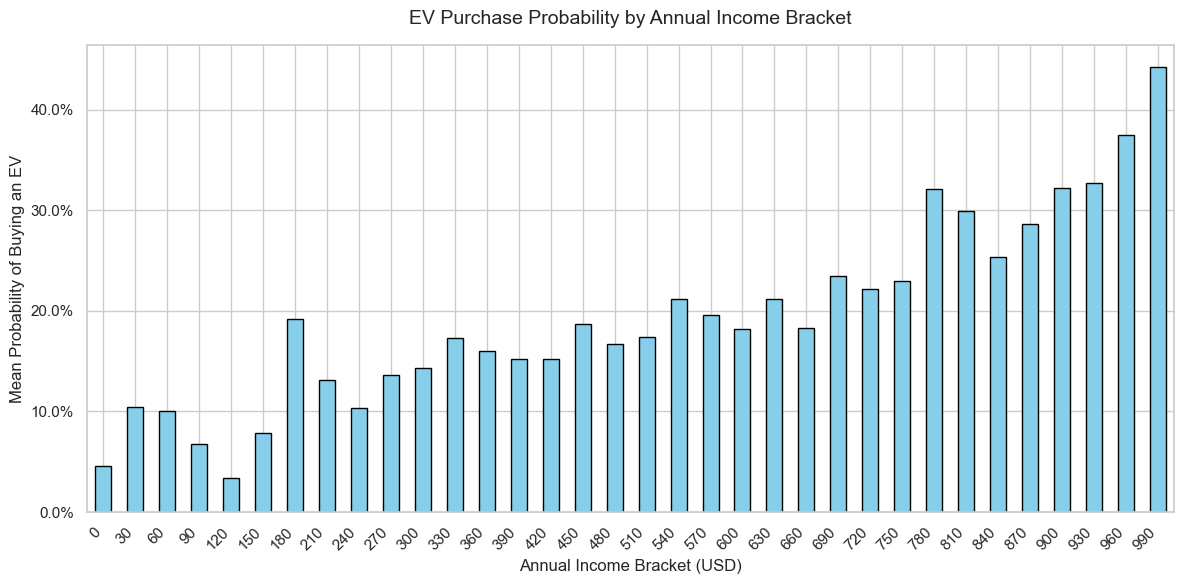

In [201]:
%matplotlib inline
import matplotlib.pyplot as plt

col_bin="Annual_Income_USD_bin_1100"
col_sort="Will_Buy_EV"
groups_size=30


col_smoothed = col_bin+f"groupby_{str(groups_size)}"

out[col_smoothed] = (out[col_bin].astype("int") // groups_size) * groups_size
#col_sort=col_bin

plot_data = (
    out.groupby(col_smoothed)
    .agg({"Will_Buy_EV": "mean", "Annual_Income_USD": "min"})
    .sort_values(by="Annual_Income_USD", ascending=True)
)  # Sorting by income minimum preserves numerical order on the X-axis

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a bar plot using pandas built-in wrapper for matplotlib
ax = plot_data["Will_Buy_EV"].plot(kind="bar", color="skyblue", edgecolor="black")

# 4. Customize labels and formatting
plt.title("EV Purchase Probability by Annual Income Bracket", fontsize=14, pad=15)
plt.xlabel("Annual Income Bracket (USD)", fontsize=12)
plt.ylabel("Mean Probability of Buying an EV", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotates labels so they don't overlap

# Optional: Format Y-axis as percentages
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/victor.loaiza/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
 

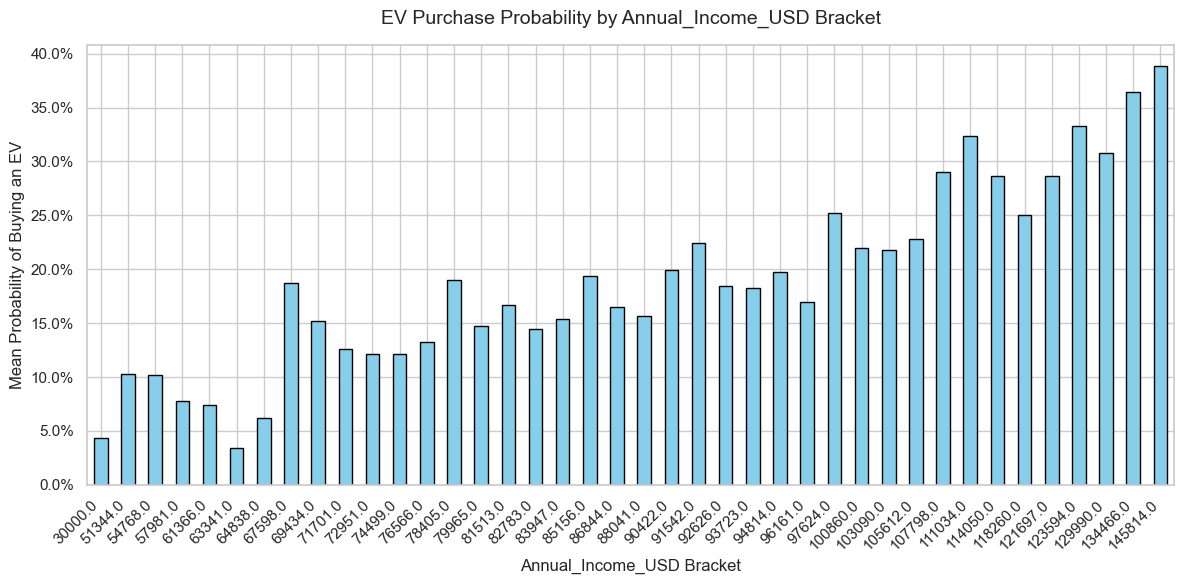

In [237]:
num_col="Annual_Income_USD"
#num_col="Daily_Commute_km"
#num_col="Age"
col_x=num_col

bin_counts = [400, 600, 800, 900, 1100]
fit_mode=True
out = df_train.copy()
if fit_mode:
    fitted_bins = {}
    for n_bins in bin_counts:
        binner = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile", subsample=None)
        binner.fit(out[[num_col]])
        fitted_bins[n_bins] = binner
for n_bins in bin_counts:
    col_name = f"{num_col}_bin_{n_bins}"
    out[col_name] = fitted_bins[n_bins].transform(out[[num_col]]).ravel().astype("int32")
    out[col_name] = out[col_name].astype("category")



col_bin=f"{num_col}_bin_1100"
col_sort="Will_Buy_EV"
groups_size=25


col_smoothed = col_bin+f"groupby_{str(groups_size)}"

out[col_smoothed] = (out[col_bin].astype("int") // groups_size) * groups_size
#col_sort=col_bin

plot_data = (
    out.groupby(col_smoothed)
    .agg({"Will_Buy_EV": "mean", num_col: "min"})
    .sort_values(by=num_col, ascending=True)
).reset_index()  # Sorting by income minimum preserves numerical order on the X-axis
plot_data = plot_data.set_index(col_x)
# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a bar plot using pandas built-in wrapper for matplotlib
ax = plot_data["Will_Buy_EV"].plot(kind="bar", color="skyblue", edgecolor="black")

# 4. Customize labels and formatting
plt.title(f"EV Purchase Probability by {num_col} Bracket", fontsize=14, pad=15)
plt.xlabel(f"{num_col} Bracket", fontsize=12)
plt.ylabel("Mean Probability of Buying an EV", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Rotates labels so they don't overlap

# Optional: Format Y-axis as percentages
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## Silver Transformation: Data Cleaning and artifact creation

In [203]:
output = silver_output_path(train_set)

DROP_COLS   = ["id"]
TARGET_RAW  = "Will_Buy_EV"
TARGET_OUT  = "will_buy_ev"


NUMERIC_COLS = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]

CATEGORICAL_COLS = ["Gender", "City_Type", "Current_Car_Type"]

# Define transformations
BINARY_COLS = {
    "Home_Charging_Possible": {"No": 0, "Yes": 1},
    "Subsidy_Available":      {"No": 0, "Yes": 1},
}

ORDINAL_COLS = {
    "Range_Anxiety_Level": {"Low": 0, "Medium": 1, "High": 2},
}

In [204]:
df= load_data(train_set)

  Loaded train.csv: (668665, 15)


In [205]:
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
# Encode target
if TARGET_RAW not in df.columns:
    raise ValueError(f"Target column '{TARGET_RAW}' not found in training data.")
df[TARGET_OUT] = (df[TARGET_RAW] == "Yes").astype(int)

df = df.drop(columns=[TARGET_RAW])
event_rate = df[TARGET_OUT].mean()
print(f"  [train] Target encoded | event rate: {event_rate:.1%} ({df[TARGET_OUT].sum():,} positives)")

  [train] Target encoded | event rate: 17.5% (116,779 positives)


In [ ]:
df["income_exact"]  = np.floor(df["Annual_Income_USD"]).astype(int).astype(str)
df["income_100"]    = (np.floor(df["Annual_Income_USD"] / 100) * 100).astype(int).astype(str)
df["income_1000"]   = (np.floor(df["Annual_Income_USD"] / 1000) * 1000).astype(int).astype(str)

df["Daily_Commute_km_exact"]  = np.floor(df["Daily_Commute_km"]).astype(int).astype(str)
#df["Age_exact"]  = np.floor(df["Age"]).astype(int).astype(str)


In [207]:
# Fit standard scaler on numeric columns
scaler_params = {}
for col in NUMERIC_COLS:
    if col not in df.columns:
        raise ValueError(f"Expected numeric column '{col}' not found in training data.")
    mean = float(df[col].mean())
    std  = float(df[col].std(ddof=0))
    if std == 0:
        raise ValueError(f"Column '{col}' has zero variance — cannot standardize.")
    scaler_params[col] = {"mean": mean, "std": std}

In [208]:
# Fit categorical label encoder on train
encoder_params = {}
for col in CATEGORICAL_COLS:
    if col not in df.columns:
        raise ValueError(f"Expected categorical column '{col}' not found in training data.")
    categories = sorted(df[col].dropna().unique().tolist())
    encoder_params[col] = {cat: idx for idx, cat in enumerate(categories)}

In [209]:
encoder_params

{'Gender': {'Female': 0, 'Male': 1, 'Other': 2},
 'City_Type': {'Rural': 0, 'Suburban': 1, 'Urban': 2},
 'Current_Car_Type': {'Hatchback': 0, 'SUV': 1, 'Sedan': 2, 'Truck': 3}}

In [210]:
# Save artifacts before transforming (so they're always from the train fit)
save_artifacts(scaler_params, encoder_params)

  Artifacts saved → /Users/victor.loaiza/Documents/Projects /Predicting Electric Vehicle Purchases/Manual/main_scripts/pipeline_artifacts/


In [211]:
# Apply transformations
df = _apply_standard_scaler(df, scaler_params)
df = _apply_encoders(df, encoder_params,BINARY_COLS ,ORDINAL_COLS , CATEGORICAL_COLS)


In [212]:
# Reorder: target last
cols = [c for c in df.columns if c != TARGET_OUT] + [TARGET_OUT]
df   = df[cols]


In [213]:
os.makedirs(os.path.dirname(output), exist_ok=True)
df.to_csv(output, index=False)
print(f"  [train] Silver layer saved → {output}  {df.shape}")


  [train] Silver layer saved → /Users/victor.loaiza/Documents/Projects /Predicting Electric Vehicle Purchases/Manual/data/Silver layer/train_cleaned.csv  (668665, 18)


## Feature interactions

In [214]:
TARGET = "will_buy_ev"


OVERALL_RATE = df[TARGET].mean()
print(f"  {df.shape}  |  event rate {OVERALL_RATE:.1%}")

CAT_COLS  = [c for c in df.columns if ((c != TARGET)&(c !="id")) and df[c].dtype == object]
FEAT_COLS = [c for c in df.columns if ((c != TARGET)&(c !="id"))]


encoders, df_enc = {}, df.copy()
for col in CAT_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

X      = df[FEAT_COLS].values.astype(float)
y      = df[TARGET].values.astype(int)
F      = len(FEAT_COLS)

  (668665, 18)  |  event rate 17.5%


In [215]:
# ── Train XGBoost ─────────────────────────────────────────────────────────────
print("\nTraining XGBoost …")
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=100,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=SEED,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0,
)
model.fit(X, y)
auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
print(f"  Train AUC: {auc:.4f}")

# Fast predict helper (avoids sklearn overhead in loops)
booster = model.get_booster()

def _predict(X_arr):
    """Return P(EV=1) for every row in X_arr."""
    return booster.predict(xgb.DMatrix(X_arr))


Training XGBoost …
  Train AUC: 0.9445


In [216]:
# ════════════════════════════════════════════════════════════════════════════════
# STEP 1 — SHAP Interaction Values
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("STEP 1 — SHAP Interaction Values")
print("═"*70)

N_SHAP = 12_000
idx_s  = RNG.choice(len(X), N_SHAP, replace=False)
X_s    = X[idx_s]

explainer = shap.TreeExplainer(model)
print(f"Computing SHAP interaction values on {N_SHAP:,} samples …")
sv = explainer.shap_interaction_values(X_s)

# Normalise output shape: want (N, F, F) for class-1 / binary
if isinstance(sv, list):
    sv = sv[1]
if sv.ndim == 4:          # some versions: (N, F, F, classes)
    sv = sv[:, :, :, 1]
assert sv.ndim == 3 and sv.shape[1] == F, f"Unexpected SHAP shape: {sv.shape}"

# Mean absolute interaction matrix  (F × F)
MAI = np.mean(np.abs(sv), axis=0)
MAIN_EFF = np.diag(MAI).copy()   # per-feature main effects (diagonal)
np.fill_diagonal(MAI, 0)          # zero diagonal — we report pure pairwise interactions

# Ranked pair table
pair_rows = [
    {'Feature_A': FEAT_COLS[i], 'Feature_B': FEAT_COLS[j],
     'SHAP_Interaction': float(MAI[i, j])}
    for i in range(F) for j in range(i+1, F)
]
shap_pairs = (pd.DataFrame(pair_rows)
              .sort_values('SHAP_Interaction', ascending=False)
              .reset_index(drop=True))

print("\nTop 15 SHAP interaction pairs:")
print(shap_pairs.head(15).to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9), facecolor='white')
fig.suptitle('SHAP Pairwise Interaction Analysis — EV Purchase Prediction',
             fontsize=14, fontweight='bold', y=1.01)

# Heatmap (symmetric, diagonal masked)
hm = MAI.copy()
hm[hm == 0] = np.nan
hm_df = pd.DataFrame(hm, index=FEAT_COLS, columns=FEAT_COLS)
sns.heatmap(hm_df, ax=axes[0], cmap='Blues', annot=True, fmt='.4f',
            linewidths=0.3, cbar_kws={'label': 'Mean |SHAP Interaction|', 'shrink': 0.75},
            mask=np.isnan(hm))
axes[0].set_title('Interaction Matrix\n(off-diagonal pairs only)',
                   fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0,  labelsize=7)

# Bar chart — top 15 pairs coloured by strength tier
n_bar  = min(15, len(shap_pairs))
top_b  = shap_pairs.head(n_bar).copy()
top_b['Pair'] = (top_b['Feature_A'].str[:17].str.rstrip('_') + ' ×\n' +
                 top_b['Feature_B'].str[:17].str.rstrip('_'))
p80 = shap_pairs['SHAP_Interaction'].quantile(0.80)
p55 = shap_pairs['SHAP_Interaction'].quantile(0.55)
bar_colors = ['#1a6faf' if v >= p80 else '#6baed6' if v >= p55 else '#c6dbef'
              for v in top_b['SHAP_Interaction']]
bars = axes[1].barh(range(n_bar), top_b['SHAP_Interaction'].values[::-1],
                    color=bar_colors[::-1], edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(n_bar))
axes[1].set_yticklabels(top_b['Pair'].values[::-1], fontsize=7)
axes[1].set_xlabel('Mean |SHAP Interaction Value|', fontsize=10)
axes[1].set_title('Top Feature Pair Interactions', fontweight='bold', fontsize=11)
patches = [mpatches.Patch(color='#1a6faf', label='Strong (top 20%)'),
           mpatches.Patch(color='#6baed6', label='Moderate (20–45%)'),
           mpatches.Patch(color='#c6dbef', label='Weak (bottom 55%)')]
axes[1].legend(handles=patches, fontsize=8, loc='lower right')

plt.tight_layout()
plot_path = os.path.join(OUT_DIR, 'ev_shap_interaction_summary.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\nPlot saved → {plot_path}")


══════════════════════════════════════════════════════════════════════
STEP 1 — SHAP Interaction Values
══════════════════════════════════════════════════════════════════════
Computing SHAP interaction values on 12,000 samples …

Top 15 SHAP interaction pairs:
                  Feature_A                   Feature_B  SHAP_Interaction
Environmental_Concern_Level           Subsidy_Available          0.131528
Environmental_Concern_Level                  income_100          0.041122
          Annual_Income_USD                  income_100          0.038328
                 income_100                 income_1000          0.033914
          Annual_Income_USD Environmental_Concern_Level          0.028233
          Annual_Income_USD                 income_1000          0.027884
          Subsidy_Available         Range_Anxiety_Level          0.027117
Environmental_Concern_Level                 income_1000          0.025989
          Subsidy_Available                 income_1000          0.02573

In [217]:
# ════════════════════════════════════════════════════════════════════════════════
# STEP 2 — H-Statistic (Friedman)
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("STEP 2 — H-Statistic (Friedman)")
print("═"*70)

N_H  = 8_000
GRID = 12
idx_h = RNG.choice(len(X), N_H, replace=False)
X_h   = X[idx_h].astype(float)

def _pdp1d(fi, grid):
    out = []
    for v in grid:
        Xc = X_h.copy(); Xc[:, fi] = v
        out.append(_predict(Xc).mean())
    return np.array(out)

def _pdp2d(fi, fj, gi, gj):
    G = np.zeros((len(gi), len(gj)))
    for ii, vi in enumerate(gi):
        for jj, vj in enumerate(gj):
            Xc = X_h.copy(); Xc[:, fi] = vi; Xc[:, fj] = vj
            G[ii, jj] = _predict(Xc).mean()
    return G

def h_stat(fi, fj, grid=GRID):
    """Friedman H-statistic for feature pair (fi, fj)."""
    gi = np.unique(np.percentile(X_h[:, fi], np.linspace(5, 95, grid)))
    gj = np.unique(np.percentile(X_h[:, fj], np.linspace(5, 95, grid)))
    if len(gi) < 2 or len(gj) < 2:
        return np.nan
    fij   = _pdp2d(fi, fj, gi, gj)
    fi_   = _pdp1d(fi, gi)
    fj_   = _pdp1d(fj, gj)
    fij_c = fij - fij.mean()
    fi_c  = fi_ - fi_.mean()
    fj_c  = fj_ - fj_.mean()
    fi_2d = np.tile(fi_c[:, None], (1, len(gj)))
    fj_2d = np.tile(fj_c[None, :], (len(gi), 1))
    num   = np.sum((fij_c - fi_2d - fj_2d)**2)
    den   = np.sum(fij_c**2)
    return float(np.sqrt(num / den)) if den > 1e-10 else 0.0

h_rows = []
print(f"Computing H-statistic for top 8 SHAP pairs (sample {N_H:,}, grid {GRID}×{GRID}) …\n")
for _, row in shap_pairs.head(8).iterrows():
    fa, fb = row['Feature_A'], row['Feature_B']
    fi, fj = FEAT_COLS.index(fa), FEAT_COLS.index(fb)
    print(f"  {fa:35s} × {fb:35s} … ", end='', flush=True)
    h = h_stat(fi, fj)
    print(f"H = {h:.4f}")
    h_rows.append({'Feature_A': fa, 'Feature_B': fb,
                   'SHAP_Interaction': row['SHAP_Interaction'],
                   'H_Statistic': h})
h_df = pd.DataFrame(h_rows)

print("\nH-statistic summary:")
print(h_df.to_string(index=False))


══════════════════════════════════════════════════════════════════════
STEP 2 — H-Statistic (Friedman)
══════════════════════════════════════════════════════════════════════
Computing H-statistic for top 8 SHAP pairs (sample 8,000, grid 12×12) …

  Environmental_Concern_Level         × Subsidy_Available                   … H = 0.5646
  Environmental_Concern_Level         × income_100                          … H = 0.1997
  Annual_Income_USD                   × income_100                          … H = 0.0976
  income_100                          × income_1000                         … H = 0.2293
  Annual_Income_USD                   × Environmental_Concern_Level         … H = 0.0699
  Annual_Income_USD                   × income_1000                         … H = 0.1515
  Subsidy_Available                   × Range_Anxiety_Level                 … H = 0.5124
  Environmental_Concern_Level         × income_1000                         … H = 0.1167

H-statistic summary:
                  

In [218]:
# ════════════════════════════════════════════════════════════════════════════════
# STEP 3 — Non-Linear Threshold Detection
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("STEP 3 — Non-Linear Threshold Detection (max_depth=4)")
print("═"*70)

THRESH_FEATS = ['Annual_Income_USD', 'Daily_Commute_km', 'Age']
thresh_rows  = []

for feat in THRESH_FEATS:
    fi  = FEAT_COLS.index(feat)
    Xf  = X[:, fi].reshape(-1, 1)
    dt  = DecisionTreeClassifier(max_depth=4, min_samples_leaf=1000, random_state=SEED)
    dt.fit(Xf, y)
    raw_splits = dt.tree_.threshold
    splits     = np.unique(np.sort(raw_splits[raw_splits > -2]))

    print(f"\n  {feat}: {len(splits)} split(s) at {[round(s, 1) for s in splits]}")

    bins = [-np.inf] + list(splits) + [np.inf]
    for k in range(len(bins) - 1):
        mask = (X[:, fi] >= bins[k]) & (X[:, fi] < bins[k+1])
        if mask.sum() == 0:
            continue
        er  = float(y[mask].mean())
        dev = round((er - OVERALL_RATE) * 100, 1)
        lo  = '' if np.isinf(bins[k])   else f'{bins[k]:.0f}'
        hi  = '' if np.isinf(bins[k+1]) else f'{bins[k+1]:.0f}'
        seg = f"[{lo or '-∞'}, {hi or '+∞'})"
        thresh_rows.append({
            'Feature': feat, 'Segment': seg,
            'N': int(mask.sum()),
            'Event_Rate': round(er, 4),
            'Dev_pp': dev,
        })
        print(f"    {seg:30s}  N={mask.sum():>7,}  ER={er:.1%}  Dev={dev:+.1f}pp")

thresh_df = pd.DataFrame(thresh_rows)


# ════════════════════════════════════════════════════════════════════════════════
# STEP 4 — Dormant Feature Re-Test
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("STEP 4 — Dormant Feature Re-Test (conditional event rates)")
print("═"*70)

USELESS = ['Age', 'City_Type', 'Current_Car_Type', 'Number_of_Cars_Owned',
           'Gender', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work']
STRONG  = ['Environmental_Concern_Level', 'Subsidy_Available',
           'Annual_Income_USD', 'Range_Anxiety_Level']
FLAG_PP = 5.0

def _bin(s, n=4):
    """Bin numeric series into quartiles; pass through categorical."""
    if s.dtype == object or s.nunique() <= n:
        return s.astype(str)
    return pd.qcut(s, q=n, labels=[f'Q{i+1}' for i in range(n)],
                   duplicates='drop').astype(str)

df_w = df.copy()
dormant_rows = []

for usl in USELESS:
    for str_f in STRONG:
        u_s = _bin(df_w[usl])
        s_s = _bin(df_w[str_f])

        pivot = (pd.DataFrame({'s': s_s, 'u': u_s, 't': y})
                 .groupby(['s', 'u'])['t']
                 .agg(['mean', 'count'])
                 .reset_index()
                 .rename(columns={'mean': 'er', 'count': 'n'}))
        pivot['dev_pp'] = (pivot['er'] - OVERALL_RATE) * 100

        # Conditional range: average spread of ER across useless-feature levels
        # WITHIN each strong-feature level (tests if useless adds info on top of strong)
        cond_range = (pivot.groupby('s')['er']
                      .apply(lambda x: x.max() - x.min() if len(x) > 1 else 0)
                      .mean() * 100)

        n_flag = int((pivot['dev_pp'].abs() > FLAG_PP).sum())
        dormant_rows.append({
            'Useless_Feature': usl,
            'Conditioned_On': str_f,
            'Cond_Range_pp': round(cond_range, 1),
            'N_Flagged_Cells': n_flag,
            'Total_Cells': len(pivot),
        })

dormant_df = (pd.DataFrame(dormant_rows)
              .sort_values('Cond_Range_pp', ascending=False)
              .reset_index(drop=True))

print("\nConditional range table (sorted by Cond_Range_pp):")
print(dormant_df.to_string(index=False))
print(f"\n  Interpretation: Cond_Range_pp is the average spread of event rates")
print(f"  across useless-feature levels WITHIN each strong-feature level.")
print(f"  A high value means the useless feature still discriminates after")
print(f"  conditioning on the strong feature.")


# ════════════════════════════════════════════════════════════════════════════════
# Build ranked interaction table
# ════════════════════════════════════════════════════════════════════════════════
full_pairs = shap_pairs.merge(
    h_df[['Feature_A', 'Feature_B', 'H_Statistic']],
    on=['Feature_A', 'Feature_B'], how='left'
)

p80 = full_pairs['SHAP_Interaction'].quantile(0.80)
p55 = full_pairs['SHAP_Interaction'].quantile(0.55)
full_pairs['Strength'] = np.where(
    full_pairs['SHAP_Interaction'] >= p80, 'Strong',
    np.where(full_pairs['SHAP_Interaction'] >= p55, 'Moderate', 'None')
)

full_pairs.to_csv(os.path.join(OUT_DIR, 'ev_interaction_ranked.csv'), index=False)
thresh_df.to_csv(os.path.join(OUT_DIR, 'ev_nonlinear_thresholds.csv'), index=False)
print(f"\nCSVs saved → claude_outputs/")


══════════════════════════════════════════════════════════════════════
STEP 3 — Non-Linear Threshold Detection (max_depth=4)
══════════════════════════════════════════════════════════════════════

  Annual_Income_USD: 14 split(s) at [np.float64(-1.3), np.float64(-1.2), np.float64(-0.8), np.float64(-0.6), np.float64(-0.5), np.float64(0.0), np.float64(0.4), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.6), np.float64(0.8), np.float64(1.5), np.float64(2.9)]
    [-∞, -1)                        N= 70,860  ER=4.5%  Dev=-13.0pp
    [-1, -1)                        N=  5,075  ER=2.0%  Dev=-15.5pp
    [-1, -1)                        N= 52,337  ER=10.0%  Dev=-7.4pp
    [-1, -1)                        N= 40,542  ER=4.3%  Dev=-13.2pp
    [-1, -1)                        N= 18,577  ER=20.1%  Dev=+2.6pp
    [-1, 0)                         N=148,607  ER=14.3%  Dev=-3.2pp
    [0, 0)                          N=130,019  ER=19.1%  Dev=+1.7pp
    [0, 0)                          N=  7,752 

In [219]:
# ════════════════════════════════════════════════════════════════════════════════
# Summary printout (used to write the report)
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*70)
print("FULL SUMMARY")
print("═"*70)
print(f"\nModel: XGBoost  |  Train AUC: {auc:.4f}")
print(f"Overall event rate: {OVERALL_RATE:.1%}")
print(f"N features: {F}  |  SHAP sample: {N_SHAP:,}  |  H-stat sample: {N_H:,}")

print("\n── Top 15 SHAP Interaction Pairs ────────────────────────────────────────")
print(shap_pairs.head(15).to_string(index=False))

print("\n── Main Effects (from SHAP diagonal) ───────────────────────────────────")
me_df = pd.DataFrame({'Feature': FEAT_COLS, 'Main_Effect': MAIN_EFF}).sort_values('Main_Effect', ascending=False)
print(me_df.to_string(index=False))

print("\n── H-Statistic Results ─────────────────────────────────────────────────")
print(h_df.to_string(index=False))

print("\n── Non-Linear Thresholds ────────────────────────────────────────────────")
print(thresh_df.to_string(index=False))

print("\n── Dormant Feature Conditional Ranges (top 14) ─────────────────────────")
print(dormant_df.to_string(index=False))

print("\n── Full Ranked Interaction Table (top 20) ───────────────────────────────")
print(full_pairs.head(20).to_string(index=False))

print("\nDone.")



══════════════════════════════════════════════════════════════════════
FULL SUMMARY
══════════════════════════════════════════════════════════════════════

Model: XGBoost  |  Train AUC: 0.9445
Overall event rate: 17.5%
N features: 17  |  SHAP sample: 12,000  |  H-stat sample: 8,000

── Top 15 SHAP Interaction Pairs ────────────────────────────────────────
                  Feature_A                   Feature_B  SHAP_Interaction
Environmental_Concern_Level           Subsidy_Available          0.131528
Environmental_Concern_Level                  income_100          0.041122
          Annual_Income_USD                  income_100          0.038328
                 income_100                 income_1000          0.033914
          Annual_Income_USD Environmental_Concern_Level          0.028233
          Annual_Income_USD                 income_1000          0.027884
          Subsidy_Available         Range_Anxiety_Level          0.027117
Environmental_Concern_Level                 incom

## Gold Transformation: Features interactions

In [220]:
with open("pipeline_artifacts/scaler_params.json") as f:
    scaler = json.load(f)

In [221]:
# Income thresholds
# ── Thresholds on z-score scale (pre-computed from scaler_params.json) ────────
# Raw source → z = (raw - mean) / std
# Income (mean=84769.27, std=28648.01): $68k→-0.5854  $109k→0.8476  $167k→2.8636
INC_BINS_Z = [-np.inf,
              to_z(scaler,"Annual_Income_USD", 68000),
              to_z(scaler,"Annual_Income_USD", 109000),
              to_z(scaler,"Annual_Income_USD", 167000),
              np.inf]
INC_LABELS  = [0, 1, 2, 3]   # ordinal: 0=Low, 1=Mid, 2=High, 3=VeryHigh

# Commute thresholds
# Commute (mean=32.16, std=18.73): 10km→-1.1830  23km→-0.4890  59km→1.4331

COMMUTE_SWEET_LOW_Z  = to_z(scaler,"Daily_Commute_km", 10)
COMMUTE_SWEET_HIGH_Z = to_z(scaler,"Daily_Commute_km", 23)
COMMUTE_LONG_Z       = to_z(scaler,"Daily_Commute_km", 59)

# Env thresholds
# Env Concern (mean=2.94, std=1.43): raw ≥4 → z≥0.7449  raw ≤2 → z≤-0.6546

ENV_HIGH_Z = to_z(scaler,"Environmental_Concern_Level", 4)
ENV_LOW_Z  = to_z(scaler,"Environmental_Concern_Level", 2)


# Silver encoding reference (from encoder_params.json / fixed mappings):
# Subsidy_Available:    No=0, Yes=1
# Range_Anxiety_Level:  Low=0, Medium=1, High=2


── Top  SHAP Interaction Pairs ────────────────────────────────────────

| Feature_A | Feature_B | SHAP_Interaction |
| :--- | :--- | ---: |
| Environmental_Concern_Level | Subsidy_Available | 0.130262 |
| Annual_Income_USD | Subsidy_Available | 0.050098 |
| Annual_Income_USD | Environmental_Concern_Level | 0.036550 |
| Subsidy_Available | Range_Anxiety_Level | 0.025999 |
| Environmental_Concern_Level | Range_Anxiety_Level | 0.015235 |
| Age | Environmental_Concern_Level | 0.013867 |


In [222]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add 10 interaction features to the Silver DataFrame in-place copy."""
    out = df.copy()

    env     = df["Environmental_Concern_Level"]   # z-scored
    income  = df["Annual_Income_USD"]              # z-scored
    commute = df["Daily_Commute_km"]               # z-scored
    subsidy = df["Subsidy_Available"]              # 0=No, 1=Yes
    anxiety = df["Range_Anxiety_Level"]            # 0=Low, 1=Medium, 2=High

    # Income segment (ordinal 0–3) — from DT analysis thresholds
    income_seg = pd.cut(income, bins=INC_BINS_Z, labels=INC_LABELS, right=False).astype(int)

    # ── Binary flags ──────────────────────────────────────────────────────────
    out["flag_env_high_x_subsidy"]       = ((env >= ENV_HIGH_Z)  & (subsidy == 1)).astype(int)
    out["flag_env_low_no_subsidy"]       = ((env <= ENV_LOW_Z)   & (subsidy == 0)).astype(int)
    out["flag_subsidy_x_low_anxiety"]    = ((subsidy == 1)        & (anxiety == 0)).astype(int)
    out["flag_high_concern_low_anxiety"] = ((env >= ENV_HIGH_Z)  & (anxiety != 2)).astype(int)
    out["flag_commute_sweet_spot"]       = ((commute >= COMMUTE_SWEET_LOW_Z) & (commute < COMMUTE_SWEET_HIGH_Z)).astype(int)
    out["flag_commute_long_haul"]        = (commute > COMMUTE_LONG_Z).astype(int)

    # ── Segment composites ────────────────────────────────────────────────────
    out["income_segment"]   = income_seg
    # Encodes the full income × anxiety grid as a single integer (0–11)
    out["income_x_anxiety"] = income_seg * 3 + anxiety

    # ── Numeric interaction features ──────────────────────────────────────────
    # income_segment+1 gives 1–4 (same scale as quartile without data-leakage)
    out["env_x_income_product"] = env * (income_seg + 1)
    # env is already z-scored; adding subsidy (0/1) shifts the distribution for Yes
    out["ev_propensity_score"]  = env + subsidy.astype(float)

    return out

In [223]:
train_set_silver=os.path.join(SILVER_DIR, "train_cleaned.csv")
test_set_silver=os.path.join(SILVER_DIR, "test_cleaned.csv")
path=train_set_silver
output = gold_output_path(path)


In [224]:
silver_cols = list(pd.read_csv(train_set_silver, nrows=0).columns)


In [225]:
df = load_data(path)


  Loaded train_cleaned.csv: (668665, 18)


In [226]:
df = engineer_features(df)


In [227]:
df

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,...,flag_env_high_x_subsidy,flag_env_low_no_subsidy,flag_subsidy_x_low_anxiety,flag_high_concern_low_anxiety,flag_commute_sweet_spot,flag_commute_long_haul,income_segment,income_x_anxiety,env_x_income_product,ev_propensity_score
0,1.472636,0.283361,-0.467597,0.394055,-0.499233,-0.033994,-1.354316,1,1,2,...,0,1,0,0,0,0,1,3,-2.708633,-1.354316
1,-0.702048,-1.911800,-1.449954,-0.977170,-0.753891,-0.998012,0.744881,1,0,1,...,0,0,0,1,0,0,0,0,0.744881,0.744881
2,-1.634055,0.335791,0.247816,-0.977170,0.774056,1.508436,1.444613,0,2,2,...,1,0,1,1,0,0,1,3,2.889227,2.444613
3,1.472636,-0.390577,-0.451580,0.394055,0.264740,0.351613,0.045149,1,1,0,...,0,0,0,0,0,0,1,3,0.090297,0.045149
4,0.540629,-0.937980,0.995261,-0.977170,-0.753891,-0.805209,0.045149,1,1,0,...,0,0,0,0,0,0,0,0,0.045149,0.045149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,-1.323386,-0.477495,-0.254041,0.394055,0.010082,-0.226798,1.444613,1,2,2,...,1,0,0,1,0,0,1,4,2.889227,2.444613
668661,-1.168051,1.578495,-1.449954,0.394055,0.010082,-0.612405,-1.354316,0,1,1,...,0,0,1,0,0,0,2,6,-4.062949,-0.354316
668662,1.317301,1.292297,-0.424885,-0.977170,0.010082,-0.226798,-1.354316,0,1,0,...,0,0,1,0,0,0,2,6,-4.062949,-0.354316
668663,0.307627,1.087466,0.616200,0.394055,-1.263206,-1.383620,-1.354316,0,0,1,...,0,0,1,0,0,0,2,6,-4.062949,-0.354316


In [228]:



new_cols = [c for c in df.columns if c not in silver_cols]
print(f"  Engineered features ({len(new_cols)}): {new_cols}")


os.makedirs(GOLD_DIR, exist_ok=True)
df.to_csv(output, index=False)
print(f"  Gold layer saved → {output}  {df.shape}")

  Engineered features (10): ['flag_env_high_x_subsidy', 'flag_env_low_no_subsidy', 'flag_subsidy_x_low_anxiety', 'flag_high_concern_low_anxiety', 'flag_commute_sweet_spot', 'flag_commute_long_haul', 'income_segment', 'income_x_anxiety', 'env_x_income_product', 'ev_propensity_score']
  Gold layer saved → /Users/victor.loaiza/Documents/Projects /Predicting Electric Vehicle Purchases/Manual/data/Gold layer/train_engineered.csv  (668665, 28)


In [229]:
df.columns

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender', 'City_Type',
       'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available',
       'Range_Anxiety_Level', 'income_exact', 'income_100', 'income_1000',
       'Daily_Commute_km_exact', 'will_buy_ev', 'flag_env_high_x_subsidy',
       'flag_env_low_no_subsidy', 'flag_subsidy_x_low_anxiety',
       'flag_high_concern_low_anxiety', 'flag_commute_sweet_spot',
       'flag_commute_long_haul', 'income_segment', 'income_x_anxiety',
       'env_x_income_product', 'ev_propensity_score'],
      dtype='object')